In [2]:
import pandas as pd

df = pd.read_csv('df_limpio_1y2.csv')

Se cargan los datos del archivo creado a partir de la limpieza de datos (tarea #3)

In [ ]:
#Separar variables predictoras(inputs) y objetivo (output)

y = df["made_sla"]
x = df.drop("made_sla", axis=1)

Teniendo en cuenta la pregunta #3 "¿Cómo puede predecirse si una solicitud cumplirá con los estándares adecuados? Creamos una copia del df para este primer modelo, de manera que se preparan los datos, eliminando el "made_sla" del df y guardándolo en otra variable, para posteriormente predecir si los factores o variables agrupados en la limpieza de datos (los que no fueron borrados) influyen en el cumplimiento de esta variable.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

Con lo anterior, se escoge la proporción de datos que se destinará para entrenar el modelo y el resto para prueba. En este caso se utilizó el 70% para entrenamiento y el 30% para prueba. Además, se escogió arbitrariamente el valor de 42 para la semilla que permitirá la generación de pseudoaleatorios; este valor permanece constante a lo largo del modelo para asegurar que la división de los datos siempre sea la misma. 

In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Como en este caso nuestro output es una variable categórica que es booleana (indica si una solicitud cumple con los estándares adecuados o no), usaremos un modelo de regresión logística. Se crea el modelo, pero se le pone un límite de 1000 iteraciones durante el entrenamiento con el propósito de que los pesos (los coeficientes que indican, en este caso, la influencia de cada variable independiente sobre la probabilidad de que una solicitud cumpla con los estándares) converjan (su valor entre iteraciones no cambie significativamente), de manera que la convergencia puede representar valores "óptimos" para los pesos, de lo contrario, puede que el modelo predictivo no tenga buenos resultados. Después se procede a entrenar el modelo con lo estipulado anteriormente. 

In [6]:
y_pred = model.predict(X_test)

En este caso se está realizando el modelo de predicción con respecto al 30% de los datos no usados, los cuales hacen referencia a los datos de prueba, pues el modelo ya fue entrenado con el 70% restante de los datos. 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, log_loss, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Log-loss (función de pérdida):", log_loss(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


Accuracy: 0.9697746624641295
Precision: 0.9778258921905331
Log-loss (función de pérdida): 1.0894315897119902
Recall: 0.9900718155474361


En este caso, se usan métricas para saber qué tan acertado es el modelo predictivo. En primera instancia, la métrica accuracy representa el porcentaje de predicciones correctas sobre el total de casos. Mide cuántas veces el modelo acertó, tanto en positivos como en negativos. Por otro lado, la métrica de precisión representa el porcentaje de predicciones positivas que realmente son positivas. En cuanto a la función de pérdida Log Loss, se usa porque penaliza de forma logarítmica los errores de predicción, lo que significa que si el modelo está muy seguro y se equivoca (confianza alta), el castigo es mucho mayor. "Recall" se centra en identificar la proporción de los datos que verdaderamente eran TRUE. No se usan métricas como MSE, RMSE, o MAE porque son más comunes y útiles para modelos predictivos de regresión lineal.

C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\User

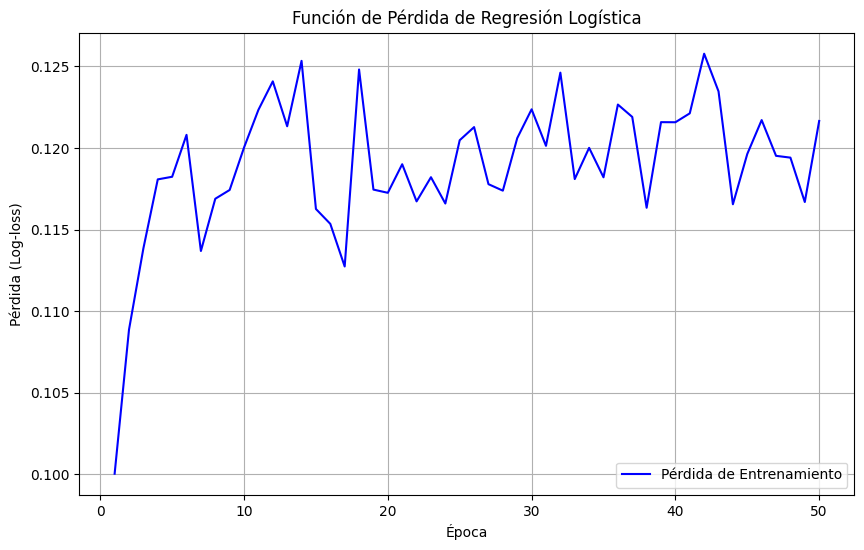

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

log_reg = SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, random_state=42)

# Esta parte se encarga de entrenar y registrar la pérdida
epocas = 50
e_perdida = []
for i in range(epocas):
    log_reg.fit(X_train, y_train)
    y_pred_proba = log_reg.predict_proba(X_train)
    loss = log_loss(y_train, y_pred_proba)
    e_perdida.append(loss)

#Gráfica de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(range(1, 50 + 1), e_perdida, 'b', label='Pérdida de Entrenamiento')
plt.title('Función de Pérdida de Regresión Logística')
plt.xlabel('Época')
plt.ylabel('Pérdida (Log-loss)')
plt.legend()
plt.grid(True)
plt.show()

El SGDClassifier de Scikit-learn es un clasificador que aprende poco a poco viendo los datos de uno en uno, como las redes neuronales (ya que los modelos de regresión usualmente analizan todos los datos a la vez), lo que nos ayuda a simular "épocas" (pasadas por los datos). Con loss='log_loss', usa una fórmula sencilla para medir errores y mejorar, tratando de minimizar este error; max_iter=1 hace que aprenda solo un paso a la vez, como una "época"; y warm_start=True le permite seguir aprendiendo desde donde quedó, sin empezar de cero. También, random_state=42 asegura que los resultados sean siempre iguales, para que se pueda ver cómo la pérdida baja en las 50 épocas simuladas. Con esto se vuelve a hacer un modelo, ya que, como se mencionó al principio, los modelos de regresión analizan todos los datos a la vez.  

Después, en cada iteración, el modelo log_reg se entrena con los datos de entrenamiento por un solo paso. El código usa el modelo para hacer predicciones en el mismo conjunto de entrenamiento y calcula su error "log_loss". Este valor de pérdida se añade a una lista llamada "train_loss". Al finalizar el bucle, la lista train_loss contiene la pérdida de cada una de las 50 épocas. Finalmente, el código utiliza la biblioteca Matplotlib para crear un gráfico de línea que muestra cómo la pérdida del modelo cambió a lo largo del entrenamiento.  

In [9]:
X_train.corr().abs

<bound method NDFrame.abs of                          active  reassignment_count  reopen_count  \
active                 1.000000            0.045340      0.017692   
reassignment_count     0.045340            1.000000      0.160878   
reopen_count           0.017692            0.160878      1.000000   
sys_mod_count         -0.095614            0.532479      0.256533   
knowledge              0.043881            0.084106      0.004709   
...                         ...                 ...           ...   
priority_2 - High      0.013931            0.031518     -0.001401   
priority_3 - Moderate -0.011249           -0.020313      0.016506   
priority_4 - Low      -0.007918           -0.003657     -0.013384   
notify_Do Not Notify   0.003834            0.007580      0.003033   
notify_Send Email     -0.003834           -0.007580     -0.003033   

                       sys_mod_count  knowledge  u_priority_confirmation  \
active                     -0.095614   0.043881                -0.

Se revisa si hay correlación entre las variables input, esto con el propósito de buscar mejoras en el modelo por medio de la eliminación de variables que representen este problema. Por esto también se hace el heatmap.

<Axes: >

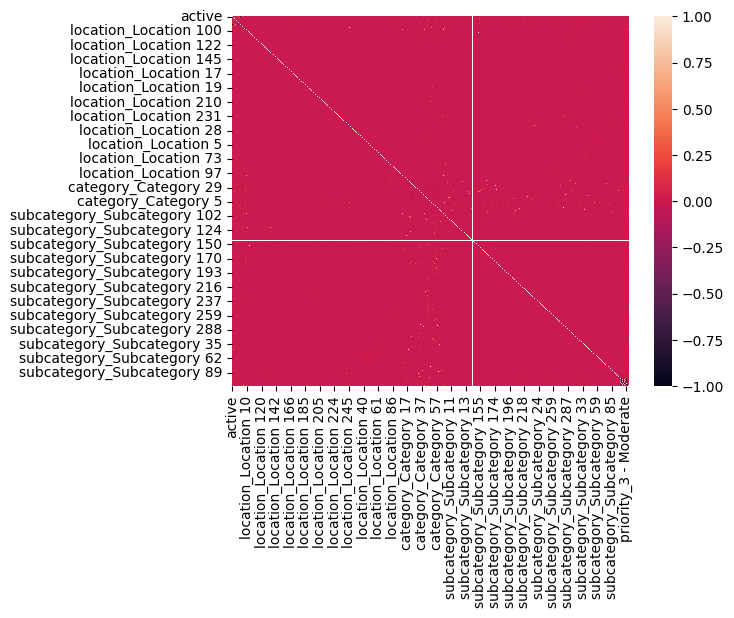

In [10]:
import seaborn as sns
sns.heatmap(X_train.corr())


Nótese que, a pesar de estar, aparentemente, bien la base de datos en términos de correlación, existen todavía variables que pueden tener correlación alta.

In [ ]:
matriz_corr = X_train.corr().abs()


# Usamos un 'stack' para convertir la matriz en una serie de pares de variables (las que revisaremos que tengan correlación alta)
serie = matriz_corr.stack()

# Filtra la serie para encontrar los valores entre 0.85 y excluyendo la diagonal, usando valor absoluto para considerar tanto correlaciones positivas como negativas. 
serie = serie[
    (serie >= 0.85) & (serie < 1.0)
]

# Convierte el resultado en un DataFrame para una mejor visualización, de lo contrario no se vería especificamente todo lo realizado anteriormente
serie_df = serie.to_frame('correlacion_abs')

print("Variables con correlación (positiva o negativa) mayor a 0.85:")
print(serie_df)

Variables con correlación (positiva o negativa) mayor a 0.85:
                                                         correlacion_abs
active                      incident_state_Closed               0.999965
incident_state_Closed       active                              0.999965
contact_type_Phone          contact_type_Self service           0.889423
contact_type_Self service   contact_type_Phone                  0.889423
category_Category 35        subcategory_Subcategory 28          0.881895
category_Category 4         subcategory_Subcategory 282         0.877045
category_Category 62        subcategory_Subcategory 192         0.881899
subcategory_Subcategory 192 category_Category 62                0.881899
subcategory_Subcategory 28  category_Category 35                0.881895
subcategory_Subcategory 282 category_Category 4                 0.877045
impact_2 - Medium           priority_3 - Moderate               0.884518
impact_3 - Low              urgency_3 - Low                   

Una vez identificadas las variables, las quitaremos del modelo para revisar si sus métricas mejoran.